<a href="https://colab.research.google.com/github/LCaravaggio/FelicidadDesigualdad/blob/main/RGB_to_NIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nirscene

In [28]:
!wget http://ivrlwww.epfl.ch/supplementary_material/cvpr11/nirscene1.zip

URL transformed to HTTPS due to an HSTS policy
--2025-06-13 18:03:17--  https://ivrlwww.epfl.ch/supplementary_material/cvpr11/nirscene1.zip
Resolving ivrlwww.epfl.ch (ivrlwww.epfl.ch)... 128.178.218.27, 2001:620:618:1da:7:80b2:da1b:1
Connecting to ivrlwww.epfl.ch (ivrlwww.epfl.ch)|128.178.218.27|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 952431486 (908M) [application/zip]
Saving to: ‘nirscene1.zip.1’

nirscene1.zip.1     100%[===================>] 908.31M  14.6MB/s    in 1m 45s  

2025-06-13 18:05:02 (8.66 MB/s) - ‘nirscene1.zip.1’ saved [952431486/952431486]



In [29]:
!unzip nirscene1.zip

Archive:  nirscene1.zip
replace nirscene1/oldbuilding/0018_rgb.tiff? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
  inflating: nirscene1/country/0018_rgb.tiff  
  inflating: nirscene1/country/0040_nir.tiff  
  inflating: nirscene1/country/0041_rgb.tiff  
  inflating: nirscene1/country/0038_nir.tiff  
  inflating: nirscene1/country/0004_nir.tiff  
  inflating: nirscene1/country/0021_nir.tiff  
  inflating: nirscene1/country/0050_nir.tiff  
  inflating: nirscene1/country/0051_rgb.tiff  
  inflating: nirscene1/country/0034_nir.tiff  
  inflating: nirscene1/country/0036_nir.tiff  
  inflating: nirscene1/country/0002_nir.tiff  
  inflating: nirscene1/country/0029_nir.tiff  
  inflating: nirscene1/country/0030_nir.tiff  
  inflating: nirscene1/country/0011_nir.tiff  
  inflating: nirscene1/country/0032_rgb.tiff  
  inflating: nirscene1/country/0051_nir.tiff  
  inflating: nirscene1/country/0023_nir.tiff  
  inflating: nirscene1/country/0000_nir.tiff  
  inflating: nirscene1/country/0017_rgb.tiff 

In [30]:
import os
import shutil
from glob import glob

# Ruta base donde están todas las imágenes mezcladas
origen = "/content/nirscene1/country"  # Reemplazar con tu ruta

# Directorios destino
carpeta_rgb = os.path.join(origen, "rgb")
carpeta_nir = os.path.join(origen, "nir")

# Crear carpetas si no existen
os.makedirs(carpeta_rgb, exist_ok=True)
os.makedirs(carpeta_nir, exist_ok=True)

# Mover archivos
for ruta_archivo in glob(os.path.join(origen, "*.tiff")):
    nombre = os.path.basename(ruta_archivo)
    if nombre.endswith("rgb.tiff"):
        shutil.move(ruta_archivo, os.path.join(carpeta_rgb, nombre))
    elif nombre.endswith("nir.tiff"):
        shutil.move(ruta_archivo, os.path.join(carpeta_nir, nombre))

In [31]:
# Entrenamiento de un modelo Pix2Pix para generar el canal NIR a partir de imágenes RGB

!pip install torchvision

import os
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm

# Dataset personalizado
class RGBNIRDataset(Dataset):
    def __init__(self, root_dir):
        self.rgb_images = sorted(glob.glob(os.path.join(root_dir, "rgb", "*.tiff")))
        self.nir_images = sorted(glob.glob(os.path.join(root_dir, "nir", "*.tiff")))
        self.transform_rgb = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
        ])
        self.transform_nir = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.rgb_images)

    def __getitem__(self, idx):
        rgb = Image.open(self.rgb_images[idx]).convert("RGB")
        nir = Image.open(self.nir_images[idx]).convert("L")
        return self.transform_rgb(rgb), self.transform_nir(nir)


# U-Net simplificado
class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 1, 4, 2, 1), nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

# Entrenamiento
def train(model, dataloader, epochs=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
    criterion = nn.L1Loss()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    for epoch in range(epochs):
        total_loss = 0
        for rgb, nir in tqdm(dataloader, desc=f"Epoch {epoch+1}"):
            rgb, nir = rgb.to(device), nir.to(device)
            pred = model(rgb)
            loss = criterion(pred, nir)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(dataloader):.4f}")

Epoch 1: 100%|██████████| 7/7 [00:18<00:00,  2.62s/it]


Epoch 1/20 - Loss: 0.6271


Epoch 2: 100%|██████████| 7/7 [00:12<00:00,  1.74s/it]


Epoch 2/20 - Loss: 0.2803


Epoch 3: 100%|██████████| 7/7 [00:12<00:00,  1.73s/it]


...

Epoch 18/20 - Loss: 0.1210


Epoch 19: 100%|██████████| 7/7 [00:13<00:00,  1.87s/it]


Epoch 19/20 - Loss: 0.1182


Epoch 20: 100%|██████████| 7/7 [00:12<00:00,  1.77s/it]


Epoch 20/20 - Loss: 0.1183


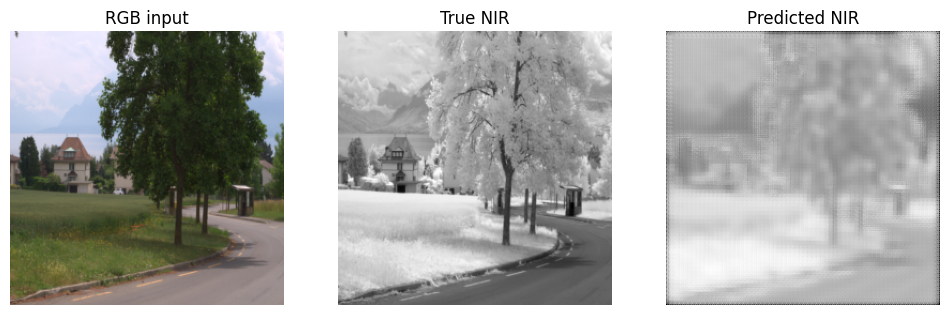

In [32]:
# Ruta con imágenes RGB y NIR
root_dir = "/content/nirscene1/country"  # Cambiar según donde pongas las imágenes
dataset = RGBNIRDataset(root_dir)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)
model = UNetGenerator()
train(model, dataloader, epochs=20)

# Visualización de resultados
def show_example(model, dataset, idx=0):
    model.eval()
    rgb, nir = dataset[idx]
    with torch.no_grad():
        pred = model(rgb.unsqueeze(0).cuda() if torch.cuda.is_available() else rgb.unsqueeze(0))
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(rgb.permute(1, 2, 0))
    axs[0].set_title("RGB input")
    axs[1].imshow(nir.squeeze(0), cmap="gray")
    axs[1].set_title("True NIR")
    axs[2].imshow(pred.squeeze(0).cpu().squeeze(), cmap="gray")
    axs[2].set_title("Predicted NIR")
    for ax in axs:
        ax.axis("off")
    plt.show()

# Visualiza un ejemplo
show_example(model, dataset, idx=0)

# EuroSat

In [33]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/eurosat-dataset


In [34]:
!pip install rasterio

In [35]:
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import rasterio
import numpy as np

class RGBNIRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.files = glob.glob(os.path.join(root_dir, '**/*.tif'), recursive=True)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        with rasterio.open(path) as src:
            img = src.read()  # shape: (13, H, W)

        # Normalizar a [0, 1] (o podés usar z-score)
        img = img.astype(np.float32)
        img /= 10000.0  # EuroSAT está en reflectancia multiplicada x10,000

        rgb = img[[1,2,3], :, :]  # bandas B2, B3, B4 → Red, Green, Blue
        nir = img[7, :, :]        # banda B8 → NIR

        # Convertir a tensores
        rgb_tensor = torch.tensor(rgb)
        nir_tensor = torch.tensor(nir).unsqueeze(0)  # shape: (1, H, W)

        return rgb_tensor, nir_tensor


In [40]:
import os
import glob
import torch
from torch.utils.data import Dataset
import numpy as np
import rasterio

class RGBNIRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.files = glob.glob(os.path.join(root_dir, '**', '*.tif'), recursive=True)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        tif_path = self.files[idx]
        with rasterio.open(tif_path) as src:
            img = src.read()  # shape: (bands, H, W)

        # Extraer bandas: Sentinel-2 EuroSAT orden típico:
        # B2 (blue), B3 (green), B4 (red), B8 (nir)
        # En EuroSAT están ordenadas: B1 (coastal), B2, ..., B13
        blue = img[1]
        green = img[2]
        red = img[3]
        nir = img[7]

        # Normalizamos los canales al rango [0, 1]
        rgb = np.stack([red, green, blue], axis=0).astype(np.float32) / 10000.0
        nir = np.expand_dims(nir, axis=0).astype(np.float32) / 10000.0

        rgb = torch.tensor(rgb)
        nir = torch.tensor(nir)

        if self.transform:
            rgb = self.transform(rgb)
            nir = self.transform(nir)

        return rgb, nir


In [44]:
dataset = RGBNIRDataset("/kaggle/input/eurosat-dataset/EuroSATallBands")
print(f"Total de imágenes encontradas: {len(dataset)}")

# Verificar una muestra
rgb, nir = dataset[0]
print("RGB shape:", rgb.shape)
print("NIR shape:", nir.shape)


Total de imágenes encontradas: 27597
RGB shape: torch.Size([3, 64, 64])
NIR shape: torch.Size([1, 64, 64])


In [36]:
# Instanciar el dataset
root_dir = "/kaggle/input/eurosat-dataset/EuroSATallBands"
dataset = RGBNIRDataset(root_dir)

# Ver cantidad de archivos encontrados
print(f"Cantidad de imágenes encontradas: {len(dataset)}")


Cantidad de imágenes encontradas: 27597


In [48]:
import torch.nn as nn
import torch.optim as optim

def train(model, dataloader, epochs=10, device='cpu'):
    model.train()
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(epochs):
        running_loss = 0.0
        for i, (rgb, nir) in enumerate(dataloader):
            rgb, nir = rgb.to(device), nir.to(device)

            optimizer.zero_grad()
            outputs = model(rgb)
            loss = criterion(outputs, nir)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if (i+1) % 50 == 0:
                print(f"Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(dataloader)}], Loss: {loss.item():.4f}")

        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {running_loss/len(dataloader):.4f}")


In [49]:
# Cargar el dataset completo
root_dir = "/kaggle/input/eurosat-dataset/EuroSATallBands"
full_dataset = RGBNIRDataset(root_dir)

# Dividimos en entrenamiento y validación
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# Modelo al dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetGenerator().to(device)

# Entrenamiento (asegúrate de tener definida la función 'train')
train(model, train_loader, epochs=10, device=device)

Epoch [1/10], Step [50/1380], Loss: 0.0178
Epoch [1/10], Step [100/1380], Loss: 0.0134
Epoch [1/10], Step [150/1380], Loss: 0.0094
Epoch [1/10], Step [200/1380], Loss: 0.0131
Epoch [1/10], Step [250/1380], Loss: 0.0130
Epoch [1/10], Step [300/1380], Loss: 0.0087
Epoch [1/10], Step [350/1380], Loss: 0.0095
Epoch [1/10], Step [400/1380], Loss: 0.0074
Epoch [1/10], Step [450/1380], Loss: 0.0089
Epoch [1/10], Step [500/1380], Loss: 0.0088
Epoch [1/10], Step [550/1380], Loss: 0.0066
Epoch [1/10], Step [600/1380], Loss: 0.0082
Epoch [1/10], Step [650/1380], Loss: 0.0085
Epoch [1/10], Step [700/1380], Loss: 0.0054
Epoch [1/10], Step [750/1380], Loss: 0.0071
Epoch [1/10], Step [800/1380], Loss: 0.0127
Epoch [1/10], Step [850/1380], Loss: 0.0048
Epoch [1/10], Step [900/1380], Loss: 0.0054
Epoch [1/10], Step [950/1380], Loss: 0.0082
Epoch [1/10], Step [1000/1380], Loss: 0.0064
Epoch [1/10], Step [1050/1380], Loss: 0.0047
Epoch [1/10], Step [1100/1380], Loss: 0.0060
Epoch [1/10], Step [1150/1380]

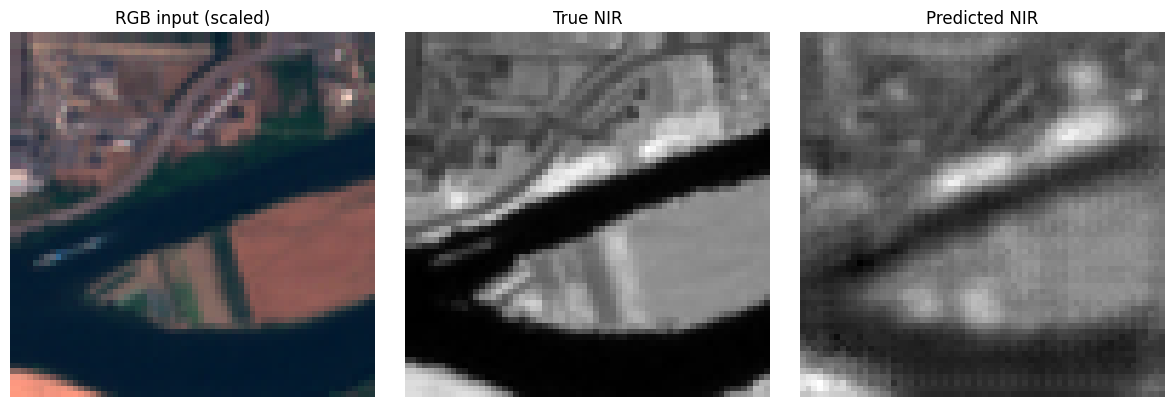

In [70]:
import matplotlib.pyplot as plt

def show_example(model, dataset, idx=0):
    model.eval()
    rgb, nir = dataset[idx]

    # Asegurarse de que los tensores sean tipo float
    rgb = rgb.float()
    nir = nir.float()

    # Normalización local del RGB para visualización
    rgb_vis = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-5)
    nir_vis = nir / nir.max() if nir.max() > 0 else nir

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    with torch.no_grad():
        input_tensor = rgb.unsqueeze(0).to(device)
        pred = model(input_tensor)
        pred_vis = pred.squeeze(0).cpu().clamp(0, 1)

    # Mostrar resultados
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(rgb_vis.permute(1, 2, 0).cpu().numpy())
    axs[0].set_title("RGB input (scaled)")
    axs[1].imshow(nir_vis.squeeze(0).cpu().numpy(), cmap="gray")
    axs[1].set_title("True NIR")
    axs[2].imshow(pred_vis.squeeze().numpy(), cmap="gray")
    axs[2].set_title("Predicted NIR")

    for ax in axs:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Visualización
show_example(model, dataset, idx=8000)  # o cualquier otro índice

In [71]:
# Guardar el modelo entrenado
torch.save(model.state_dict(), "unet_rgb2nir.pth")